In [139]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [ ]:
def update(robot):
    # Distance to object parameters 
    g_mag = np.linalg.norm(obj - robot)
    g_star = 4 # object influence radius

    # Foce parameters 
    k_a = 0.1 # head in the general direction of the goal
    k_r = 0.2

    # Attractive force
    F_a = -k_a * (robot-goal) # parabolic attraction 

    # Repulsive force
    if g_mag <= g_star:
        F_r = -k_r * ((1/g_star) - (1/g_mag)) * (1 / (g_mag**3)) * (robot - obj)
    else:
        F_r = np.zeros(2)

    # Resultant force
    F = F_a + F_r  

    return (F_a, F_r, F)

In [157]:
N = 50

goal = np.array([4.0, 8.0])
obj = np.array([3.0, 5.0]) 

robot = np.zeros([2, N+1])
robot[:, 0] = 1.0
initial = robot[:, 0]

for k in range(0, N):
    F_a, F_r, F = update(robot[:, k])
    robot[:, k+1] = robot[:, k] + F

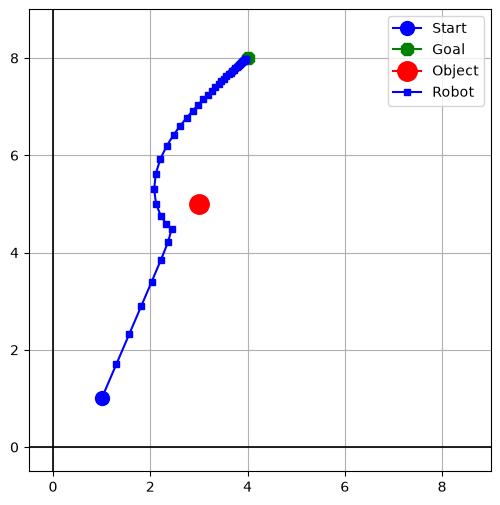

In [158]:
plt.figure(figsize=(6, 6))


plt.plot(initial[0], initial[1], 
         color='blue', marker='o', linestyle='-', markersize=10,
         label='Start')
plt.plot(goal[0], goal[1], 
         color='green', marker='8', linestyle='-', markersize=10,
         label='Goal')
plt.plot(obj[0], obj[1], 
         color='red', marker='o', linestyle='-', markersize=14 ,
         label='Object')

plt.plot(robot[0, :], robot[1, :], 
         color='blue', marker='s', linestyle='-', markersize=5,
         label='Robot')

# # Plot the 3 matching vectors
# plt.quiver(robot[0], robot[1], F_a[0], F_a[1], color='orange', label=r'$F_a$',
#            angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

# plt.quiver(robot[0], robot[1], F_r[0], F_r[1], color='purple', label=r'$F_r$',
#            angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

# plt.quiver(robot[0], robot[1], F[0], F[1], color='pink', label=r'$F_{net}$',
#            angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

plt.legend()

# Set your view limits so (0,0) is in the bottom-left and everything fits
plt.xlim(-0.5, 9)
plt.ylim(-0.5, 9)

# Formatting
plt.grid(True)
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)
plt.gca().set_aspect('equal')
plt.legend()

plt.show()